# Cross-Market Arbitrage — Buy in DE, Resell in IT

Applies three models to the latest German daily scrape:
1. **DE price model** — what is this car worth in Germany?
2. **IT price model** — what would this car fetch in Italy?
3. **DE sale model** — how fast will it sell in Germany (P(sold ≤ 14d))?

**Arbitrage score** = `net_margin_eur × sale_prob_14d`  
where `net_margin = IT predicted price − DE asking price − transaction costs (€2,500)`

Run `01_italy_price_model.ipynb` first to generate `saved_models/it_price_model_best.pkl`.

In [1]:
from __future__ import annotations

import json
import warnings
from datetime import datetime
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import shap

warnings.filterwarnings("ignore")

# ── Transaction cost model (€) ─────────────────────────────────────────────────
TRANSACTION_COSTS = {
    "transport_de_to_it_eur":   1_000,
    "italian_registration_eur":   800,
    "buffer_eur":                 700,
}
TOTAL_TRANSACTION_COST = sum(TRANSACTION_COSTS.values())  # €2,500

# ── Deal filters ───────────────────────────────────────────────────────────────
MIN_NET_MARGIN_EUR  = 1_500
MIN_SALE_PROB_14D   = 0.50
MIN_PRICE_EUR       = 15_000

# ── Model paths ────────────────────────────────────────────────────────────────
DE_PRICE_MODEL_PATH = Path("../Models/saved_models/price_model_best1.pkl")
IT_PRICE_MODEL_PATH = Path("saved_models/it_price_model_best.pkl")
DE_SALE_MODEL_PATH  = Path("../Models/saved_models/sale_model_best1.pkl")
DE_PRICE_META_PATH  = Path("../Models/saved_models/price_model_meta.json")
IT_PRICE_META_PATH  = Path("saved_models/it_price_model_meta.json")
DE_SALE_META_PATH   = Path("../Models/saved_models/sale_model_meta.json")

MODEL_POWER_MAP = {"35": 125, "40": 150, "45": 195, "50": 220, "55": 250}

print(f"Transaction costs: {TRANSACTION_COSTS}")
print(f"Total: €{TOTAL_TRANSACTION_COST:,}")
print(f"Filters: net_margin > €{MIN_NET_MARGIN_EUR:,}, sale_prob > {MIN_SALE_PROB_14D:.0%}, price > €{MIN_PRICE_EUR:,}")

Transaction costs: {'transport_de_to_it_eur': 1000, 'italian_registration_eur': 800, 'buffer_eur': 700}
Total: €2,500
Filters: net_margin > €1,500, sale_prob > 50%, price > €15,000


## 1 — Feature Engineering Helpers (from Models/03_deal_finder.ipynb)

In [2]:
def parse_number(series):
    return pd.to_numeric(
        series.astype('string')
              .str.extract(r'([0-9][0-9,.]*)', expand=False)
              .str.replace(',', '', regex=False),
        errors='coerce'
    )


def parse_bool_col(series):
    return series.astype('string').str.lower().map({'true': True, 'false': False}).astype('boolean')


def engineer_features(df_raw, reference_date=None):
    df = df_raw.copy()
    ref = reference_date or pd.Timestamp.today()

    df['price_eur']               = parse_number(df.get('price', pd.Series(dtype=str)))
    df['mileage_km']              = parse_number(df.get('mileage', pd.Series(dtype=str)))
    df['electric_range_km']       = parse_number(df.get('electric_range', pd.Series(dtype=str)))
    df['electric_range_city_km']  = parse_number(df.get('electric_range_city', pd.Series(dtype=str)))
    df['battery_charging_time_min'] = parse_number(df.get('battery_charging_time', pd.Series(dtype=str)))
    df['warranty_months']         = parse_number(df.get('warranty_text', pd.Series(dtype=str)))

    for col in ['power_kw', 'power_hp', 'seller_rating_stars', 'seller_rating_count',
                'image_count', 'previous_owner_count', 'door_count', 'seat_count']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    df['first_registration_dt'] = pd.to_datetime(
        '01/' + df['first_registration'].astype('string'),
        format='%d/%m/%Y', errors='coerce'
    )
    df['vehicle_age_months'] = (
        (ref.year  - df['first_registration_dt'].dt.year)  * 12
        + (ref.month - df['first_registration_dt'].dt.month)
    ).clip(lower=0)

    text = (
        df.get('title', pd.Series('')).fillna('') + ' ' +
        df.get('subtitle', pd.Series('')).fillna('')
    ).str.lower()

    df['is_sportback'] = df.get('variant', pd.Series('')).astype('string').str.strip().eq('Q4 e-tron Sportback')
    df['is_quattro']   = text.str.contains('quattro', regex=False)
    df['is_s_line']    = text.str.contains(r's line|s-line', regex=True)
    df['has_matrix']   = text.str.contains('matrix', regex=False)
    df['has_pano']     = text.str.contains(r'pano|panorama', regex=True)
    df['has_ahk']      = text.str.contains('ahk', regex=False)
    df['has_hud']      = text.str.contains(r'hud|head-up|head up', regex=True)
    df['has_acc']      = text.str.contains(r'\bacc\b', regex=True)
    df['has_camera']   = text.str.contains(r'kamera|camera|rfk', regex=True)

    df['model_number_v2'] = text.str.extract(
        r'(?:q4\s*)?(35|40|45|50|55)\s*(?:e[- ]?tron|quattro|qu\.\|\b)',
        expand=False
    )

    df['mileage_per_month']  = df['mileage_km'] / df['vehicle_age_months'].replace(0, np.nan)
    df['price_per_kw']       = df['price_eur'] / df['power_kw'].replace(0, np.nan)
    df['price_per_hp']       = df['price_eur'] / df['power_hp'].replace(0, np.nan)
    df['price_per_range_km'] = df['price_eur'] / df['electric_range_km'].replace(0, np.nan)

    for raw_col, clean_col in [
        ('is_conditional_price', 'is_conditional_price_clean'),
        ('available_now',        'available_now_clean'),
        ('warranty_exists',      'warranty_exists_clean'),
        ('has_full_service_history', 'has_full_service_history_clean'),
        ('had_accident',         'had_accident_clean'),
    ]:
        src = raw_col if raw_col in df.columns else clean_col
        df[clean_col] = parse_bool_col(df.get(src, pd.Series(dtype=str)))

    df['seller_has_rating']   = df['seller_rating_stars'].notna().astype(int)
    df['has_warranty_months'] = df['warranty_months'].notna().astype(int)
    df['has_battery_info']    = df.get('battery_ownership', pd.Series(dtype=str)).notna().astype(int)
    df['has_city_range']      = df['electric_range_city_km'].notna().astype(int)
    df['has_charging_time']   = df['battery_charging_time_min'].notna().astype(int)
    df['duplicate_listing_id'] = df.get('listing_id', pd.Series(dtype=str)).duplicated(keep=False).astype(int)

    # Add power_kw_imputed for IT model
    df['power_kw_imputed'] = df['model_number_v2'].map(MODEL_POWER_MAP).astype(float)

    return df


print("Feature engineering functions defined.")

Feature engineering functions defined.


## 2 — Load Models & Latest DE Scrape

In [3]:
# Load models
de_price_model = joblib.load(DE_PRICE_MODEL_PATH)
it_price_model = joblib.load(IT_PRICE_MODEL_PATH)
de_sale_model  = joblib.load(DE_SALE_MODEL_PATH)
print(f"DE price model loaded: {DE_PRICE_MODEL_PATH}")
print(f"IT price model loaded: {IT_PRICE_MODEL_PATH}")
print(f"DE sale model  loaded: {DE_SALE_MODEL_PATH}")

# Load feature column lists from meta
with open(DE_PRICE_META_PATH) as f:
    de_price_meta = json.load(f)
with open(IT_PRICE_META_PATH) as f:
    it_price_meta = json.load(f)
with open(DE_SALE_META_PATH) as f:
    de_sale_meta = json.load(f)

DE_PRICE_FEATURE_COLS = de_price_meta['feature_cols']
IT_FEATURE_COLS       = it_price_meta['feature_cols']
DE_SALE_FEATURE_COLS  = de_sale_meta['feature_cols']
DE_USE_LOG = de_price_meta.get('use_log_target', True)
IT_USE_LOG = it_price_meta.get('use_log_target', True)

print(f"\nDE price features: {len(DE_PRICE_FEATURE_COLS)}")
print(f"IT price features: {len(IT_FEATURE_COLS)}")
print(f"DE sale features:  {len(DE_SALE_FEATURE_COLS)}")

DE price model loaded: ../Models/saved_models/price_model_best1.pkl
IT price model loaded: saved_models/it_price_model_best.pkl
DE sale model  loaded: ../Models/saved_models/sale_model_best1.pkl

DE price features: 42
IT price features: 27
DE sale features:  46


In [4]:
# Load latest DE secondary scrape
scrape_dir = Path("../Scrape")
secondary_csvs = sorted(
    [p for p in scrape_dir.glob("scrape_audi_q4_*_secondary.csv")
     if not p.stem.endswith("lifecycle")],
    key=lambda p: p.stat().st_mtime,
    reverse=True,
)
if not secondary_csvs:
    raise FileNotFoundError("No DE secondary CSVs found in ../Scrape/")

latest_csv = secondary_csvs[0]
print(f"Latest DE scrape: {latest_csv.name}")

raw_df = pd.read_csv(latest_csv)
print(f"Rows: {len(raw_df)}")

df_eng = engineer_features(raw_df)
print(f"After feature engineering: {df_eng.shape}")

Latest DE scrape: scrape_audi_q4_20260514_secondary.csv
Rows: 1365
After feature engineering: (1365, 91)


## 3 — Apply All Three Models

In [5]:
def prepare_for_model(df, feature_cols, meta):
    """Prepare a DataFrame for a saved sklearn pipeline.

    - Categorical columns → string (with 'missing' for NaN), so the OHE sees them correctly.
    - Binary columns (bool / pandas Boolean) → numeric 0/1.
    - Numeric columns → kept as-is (imputer handles NaN).
    """
    X = df.reindex(columns=feature_cols).copy()

    cat_cols = meta.get('categorical_ordinal', []) + meta.get('categorical_nominal', [])
    bin_cols = meta.get('binary_features', [])

    for col in cat_cols:
        if col in X.columns:
            X[col] = X[col].astype(str).replace('nan', 'missing').replace('None', 'missing')

    for col in bin_cols:
        if col in X.columns:
            X[col] = pd.to_numeric(
                X[col].astype(str).str.lower()
                .map({'true': 1, 'false': 0, '1': 1, '0': 0,
                      '1.0': 1, '0.0': 0, 'nan': np.nan}),
                errors='coerce',
            )
    return X


# --- DE price model: what is this car worth in Germany? ---
X_de = prepare_for_model(df_eng, DE_PRICE_FEATURE_COLS, de_price_meta)
pred_raw = de_price_model.predict(X_de)
df_eng['de_fair_price'] = np.expm1(pred_raw) if DE_USE_LOG else pred_raw
print(f"DE fair price — median: €{df_eng['de_fair_price'].median():,.0f}  "
      f"range: €{df_eng['de_fair_price'].min():,.0f}–€{df_eng['de_fair_price'].max():,.0f}")

# --- IT price model: what would this car fetch in Italy? ---
X_it = prepare_for_model(df_eng, IT_FEATURE_COLS, it_price_meta)
pred_raw = it_price_model.predict(X_it)
df_eng['it_predicted_price'] = np.expm1(pred_raw) if IT_USE_LOG else pred_raw
print(f"IT predicted price — median: €{df_eng['it_predicted_price'].median():,.0f}  "
      f"range: €{df_eng['it_predicted_price'].min():,.0f}–€{df_eng['it_predicted_price'].max():,.0f}")

# --- DE sale model: how fast will it sell in Germany? ---
X_sale = prepare_for_model(df_eng, DE_SALE_FEATURE_COLS, de_sale_meta)
df_eng['sale_prob_14d'] = de_sale_model.predict_proba(X_sale)[:, 1]
print(f"Sale probability — mean: {df_eng['sale_prob_14d'].mean():.1%}  "
      f"range: {df_eng['sale_prob_14d'].min():.1%}–{df_eng['sale_prob_14d'].max():.1%}")

DE fair price — median: €38,651  range: €22,146–€74,630
IT predicted price — median: €38,259  range: €26,091–€60,486


Sale probability — mean: 36.5%  range: 3.5%–95.7%


## 4 — Arbitrage Score Computation

In [6]:
df_eng['de_discount_eur']  = df_eng['de_fair_price'] - df_eng['price_eur']
df_eng['gross_margin_eur'] = df_eng['it_predicted_price'] - df_eng['price_eur']
df_eng['net_margin_eur']   = df_eng['gross_margin_eur'] - TOTAL_TRANSACTION_COST
df_eng['it_premium_pct']   = (df_eng['it_predicted_price'] / df_eng['price_eur'] - 1) * 100
df_eng['arbitrage_score']  = (
    df_eng['net_margin_eur'].clip(lower=0) * df_eng['sale_prob_14d']
).round(0)

# Filter to genuine opportunities
deals = df_eng[
    (df_eng['net_margin_eur']     > MIN_NET_MARGIN_EUR) &
    (df_eng['sale_prob_14d']      > MIN_SALE_PROB_14D) &
    (df_eng['price_eur']          > MIN_PRICE_EUR) &
    (df_eng['it_predicted_price'] > df_eng['price_eur']) &
    (df_eng['price_eur'].notna())
].sort_values('arbitrage_score', ascending=False).reset_index(drop=True)
deals.index += 1  # 1-based rank

print(f"Total DE listings: {len(df_eng)}")
print(f"Arbitrage opportunities found: {len(deals)}")
print(f"\nSummary:")
print(f"  Total gross margin available: €{deals['gross_margin_eur'].sum():,.0f}")
print(f"  Total net margin after costs: €{deals['net_margin_eur'].sum():,.0f}")
print(f"  Average net margin per deal:  €{deals['net_margin_eur'].mean():,.0f}")
print(f"  Average sale probability:      {deals['sale_prob_14d'].mean():.1%}")
print(f"  Average IT premium:            {deals['it_premium_pct'].mean():.1f}%")

Total DE listings: 1365
Arbitrage opportunities found: 61

Summary:
  Total gross margin available: €375,943
  Total net margin after costs: €223,443
  Average net margin per deal:  €3,663
  Average sale probability:      63.9%
  Average IT premium:            18.0%


## 5 — Ranked Deal Table

In [7]:
DISPLAY_COLS = [
    'title', 'price_eur', 'de_fair_price', 'de_discount_eur',
    'it_predicted_price', 'gross_margin_eur', 'net_margin_eur',
    'it_premium_pct', 'sale_prob_14d', 'arbitrage_score',
    'model_number_v2', 'variant', 'mileage_km', 'vehicle_age_months',
    'city', 'seller_name', 'listing_url',
]

# Format for display
disp = deals[DISPLAY_COLS].copy()
for col in ['price_eur','de_fair_price','de_discount_eur','it_predicted_price',
            'gross_margin_eur','net_margin_eur','arbitrage_score']:
    disp[col] = disp[col].map(lambda x: f'€{x:,.0f}' if pd.notna(x) else '-')
disp['it_premium_pct'] = disp['it_premium_pct'].map(lambda x: f'{x:.1f}%' if pd.notna(x) else '-')
disp['sale_prob_14d']  = disp['sale_prob_14d'].map(lambda x: f'{x:.1%}' if pd.notna(x) else '-')
disp['mileage_km']     = disp['mileage_km'].map(lambda x: f'{x:,.0f}' if pd.notna(x) else '-')
disp['vehicle_age_months'] = disp['vehicle_age_months'].map(lambda x: f'{x:.0f}' if pd.notna(x) else '-')

pd.set_option('display.max_colwidth', 50)
pd.set_option('display.max_rows', 30)
print(f"Top {min(20, len(deals))} Arbitrage Opportunities")
print("="*80)
display(disp.head(20))

Top 20 Arbitrage Opportunities


,title,price_eur,de_fair_price,de_discount_eur,it_predicted_price,gross_margin_eur,net_margin_eur,it_premium_pct,sale_prob_14d,arbitrage_score,model_number_v2,variant,mileage_km,vehicle_age_months,city,seller_name,listing_url
1,Audi Q4 e-tron 50 quattro 82kWh Kamera/ACC/LED...,"€25,999","€25,645",€-354,"€33,850","€7,851","€5,351",30.2%,82.4%,"€4,412",50,Q4 e-tron,"121,612",43,Ergolding,auto mega store gmbh,https://www.autoscout24.com/offers/audi-q4-e-t...
2,Audi Q4 e-tron 35 *LED *Standheizung *PDC *DAB...,"€24,790","€27,218","€2,428","€32,766","€7,976","€5,476",32.2%,76.0%,"€4,160",NaN,Q4 e-tron,"47,000",38,Finnentrop,Auerswald Automobile,https://www.autoscout24.com/offers/audi-q4-e-t...
3,"Audi Q4 e-tron SUV (mit Eroberung BEV) SITZHG,...","€37,990","€39,012","€1,022","€46,241","€8,251","€5,751",21.7%,70.7%,"€4,067",NaN,Q4 e-tron,0,-,Mühldorf am Inn,Autohaus Ostermaier GmbH,https://www.autoscout24.com/offers/audi-q4-e-t...
4,Audi Q4 e-tron Q4 SUV (mit Eroberung BEV) SITZ...,"€37,990","€39,012","€1,022","€46,241","€8,251","€5,751",21.7%,70.7%,"€4,067",NaN,Q4 e-tron,0,-,Mühldorf am Inn,Autohaus Ostermaier GmbH,https://www.autoscout24.com/offers/audi-q4-e-t...
5,Audi Q4 e-tron Q4 SUV e-tron,"€36,490","€37,687","€1,197","€47,101","€10,611","€8,111",29.1%,50.1%,"€4,062",NaN,Q4 e-tron,0,-,Düsseldorf,Autohaus Adelbert Moll GmbH & Co. KG,https://www.autoscout24.com/offers/audi-q4-e-t...
6,Audi Q4 e-tron Q4 SUV e-tron,"€36,490","€37,687","€1,197","€47,101","€10,611","€8,111",29.1%,50.1%,"€4,062",NaN,Q4 e-tron,0,-,Düsseldorf,Autohaus Adelbert Moll GmbH & Co. KG,https://www.autoscout24.com/offers/audi-q4-e-t...
7,Audi Q4 e-tron Q4 SUV e-tron NEUBESTELLUNG MJ ...,"€38,590","€40,570","€1,980","€46,652","€8,062","€5,562",20.9%,70.5%,"€3,920",NaN,Q4 e-tron,0,-,Kassel,Audi Zentrum Kassel GmbH & Co.KG,https://www.autoscout24.com/offers/audi-q4-e-t...
8,Audi Q4 e-tron Sportback advanced 35 e-tron LE...,"€25,980","€26,220",€240,"€34,179","€8,199","€5,699",31.6%,67.8%,"€3,865",35,Q4 e-tron Sportback,"23,590",37,Schwabach,Feser GmbH,https://www.autoscout24.com/offers/audi-q4-e-t...
9,Audi Q4 e-tron 55 quattro Leder/RFK/20''/Assi-...,"€41,980","€43,453","€1,473","€49,611","€7,631","€5,131",18.2%,66.4%,"€3,406",55,Q4 e-tron,"11,036",26,Neumarkt,Fischer Automobile GmbH,https://www.autoscout24.com/offers/audi-q4-e-t...
10,"Audi Q4 e-tron e-tron Sportback 40 e-tron 20""","€28,999","€29,128",€129,"€35,385","€6,386","€3,886",22.0%,84.7%,"€3,292",40,Q4 e-tron Sportback,"47,260",32,Bornheim,Kfz Handel Rene Serwuschok,https://www.autoscout24.com/offers/audi-q4-e-t...


## 6 — Visualisations

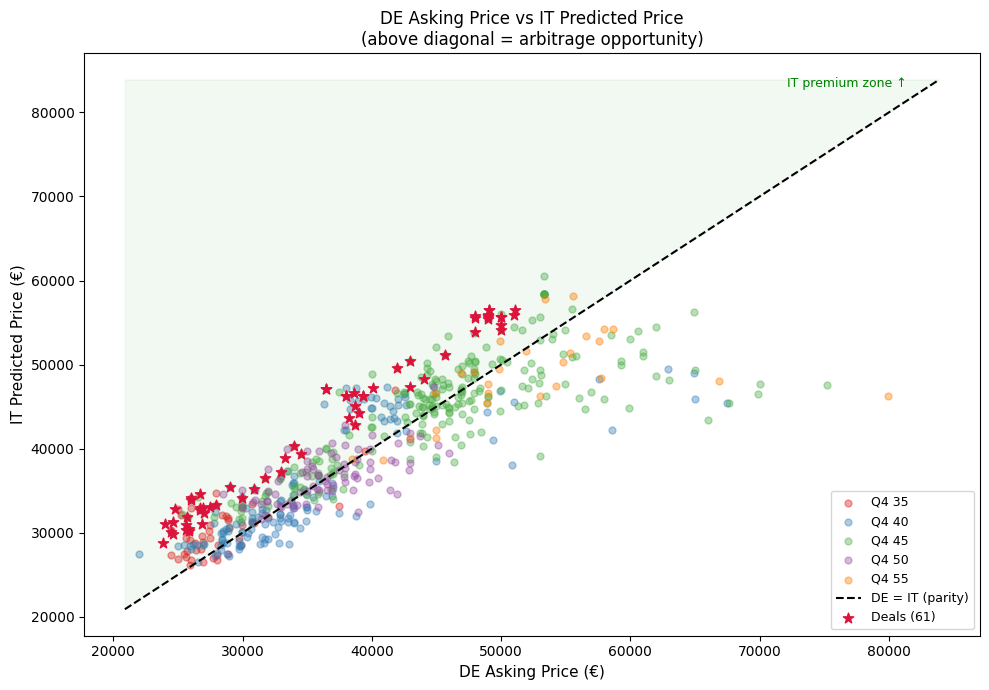

In [8]:
tier_colors = {'35':'#e41a1c','40':'#377eb8','45':'#4daf4a','50':'#984ea3','55':'#ff7f00'}

# ── Plot 1: DE asking price vs IT predicted price ─────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))

df_plot = df_eng[df_eng['price_eur'].notna() & df_eng['it_predicted_price'].notna()].copy()
df_plot['tier'] = df_plot['model_number_v2'].fillna('unknown')

for tier, color in tier_colors.items():
    mask = df_plot['tier'] == tier
    ax.scatter(df_plot.loc[mask, 'price_eur'], df_plot.loc[mask, 'it_predicted_price'],
               alpha=0.4, s=25, color=color, label=f'Q4 {tier}')

# Parity line
lim = (min(df_plot['price_eur'].min(), df_plot['it_predicted_price'].min()) * 0.95,
       max(df_plot['price_eur'].max(), df_plot['it_predicted_price'].max()) * 1.05)
ax.plot(lim, lim, 'k--', lw=1.5, label='DE = IT (parity)')
ax.fill_between(lim, lim, [lim[1], lim[1]], alpha=0.05, color='green')
ax.text(lim[1]*0.97, lim[1]*0.99, 'IT premium zone ↑', ha='right', color='green', fontsize=9)

# Highlight deal listings
if len(deals) > 0:
    ax.scatter(deals['price_eur'].astype(float).str.replace('€','').str.replace(',','').astype(float)
               if deals['price_eur'].dtype == object else deals['price_eur'],
               deals['it_predicted_price'].astype(float).str.replace('€','').str.replace(',','').astype(float)
               if deals['it_predicted_price'].dtype == object else deals['it_predicted_price'],
               s=60, color='crimson', marker='*', zorder=5, label=f'Deals ({len(deals)})')

ax.set_xlabel('DE Asking Price (€)', fontsize=11)
ax.set_ylabel('IT Predicted Price (€)', fontsize=11)
ax.set_title('DE Asking Price vs IT Predicted Price\n(above diagonal = arbitrage opportunity)', fontsize=12)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

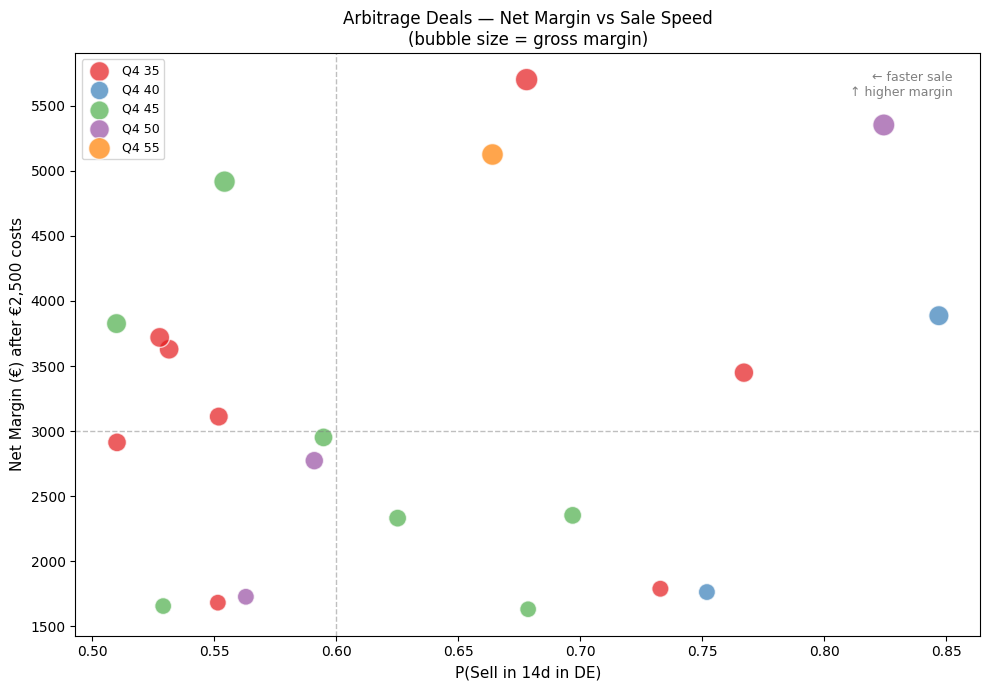

In [9]:
# ── Plot 2: Bubble chart — Net Margin vs Sale Probability ─────────────────────
if len(deals) > 0:
    fig, ax = plt.subplots(figsize=(10, 7))

    # Work with numeric deals (pre-format)
    d_num = df_eng[
        (df_eng['net_margin_eur'] > MIN_NET_MARGIN_EUR) &
        (df_eng['sale_prob_14d']  > MIN_SALE_PROB_14D) &
        (df_eng['price_eur']      > MIN_PRICE_EUR) &
        (df_eng['it_predicted_price'] > df_eng['price_eur']) &
        (df_eng['price_eur'].notna())
    ].copy()

    sizes = (d_num['gross_margin_eur'].clip(lower=0) / d_num['gross_margin_eur'].max() * 300 + 30)

    for tier, color in tier_colors.items():
        mask = d_num['model_number_v2'].fillna('unknown') == tier
        ax.scatter(d_num.loc[mask, 'sale_prob_14d'], d_num.loc[mask, 'net_margin_eur'],
                   s=sizes[mask], color=color, alpha=0.7, label=f'Q4 {tier}', edgecolors='white')

    ax.axvline(0.6, color='gray', lw=1, ls='--', alpha=0.5)
    ax.axhline(3000, color='gray', lw=1, ls='--', alpha=0.5)
    ax.set_xlabel('P(Sell in 14d in DE)', fontsize=11)
    ax.set_ylabel('Net Margin (€) after €2,500 costs', fontsize=11)
    ax.set_title('Arbitrage Deals — Net Margin vs Sale Speed\n(bubble size = gross margin)', fontsize=12)
    ax.legend(fontsize=9)
    ax.text(0.97, 0.97, '← faster sale\n↑ higher margin', transform=ax.transAxes,
            ha='right', va='top', fontsize=9, color='gray')
    plt.tight_layout()
    plt.show()
else:
    print("No deals found for bubble chart.")

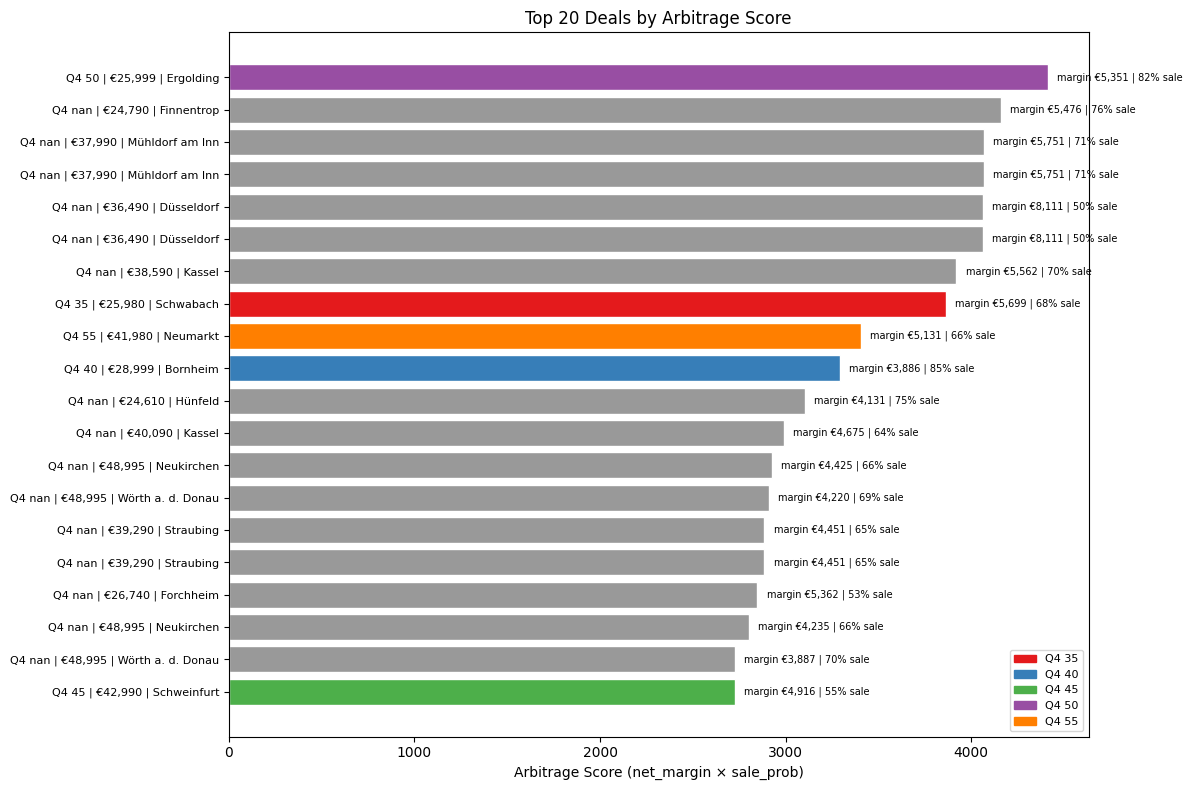

In [10]:
# ── Plot 3: Top 20 deals by arbitrage score ────────────────────────────────────
if len(deals) > 0:
    d_num = df_eng[
        (df_eng['net_margin_eur'] > MIN_NET_MARGIN_EUR) &
        (df_eng['sale_prob_14d']  > MIN_SALE_PROB_14D) &
        (df_eng['price_eur']      > MIN_PRICE_EUR) &
        (df_eng['it_predicted_price'] > df_eng['price_eur']) &
        (df_eng['price_eur'].notna())
    ].sort_values('arbitrage_score', ascending=False).head(20)

    labels = [f"Q4 {row['model_number_v2']} | €{row['price_eur']:,.0f} | {row.get('city','?')}"
              for _, row in d_num.iterrows()]

    colors_bar = [tier_colors.get(str(m), '#999999') for m in d_num['model_number_v2'].fillna('unknown')]

    fig, ax = plt.subplots(figsize=(12, 8))
    bars = ax.barh(range(len(d_num)), d_num['arbitrage_score'], color=colors_bar, edgecolor='white')
    ax.set_yticks(range(len(d_num)))
    ax.set_yticklabels(labels, fontsize=8)
    ax.invert_yaxis()
    ax.set_xlabel('Arbitrage Score (net_margin × sale_prob)', fontsize=10)
    ax.set_title('Top 20 Deals by Arbitrage Score', fontsize=12)

    for i, (bar, row) in enumerate(zip(bars, d_num.itertuples())):
        ax.text(bar.get_width() + 50, i,
                f'margin €{row.net_margin_eur:,.0f} | {row.sale_prob_14d:.0%} sale',
                va='center', fontsize=7)

    patches = [mpatches.Patch(color=c, label=f'Q4 {t}') for t, c in tier_colors.items()]
    ax.legend(handles=patches, loc='lower right', fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    print("No deals found.")

Costs €1,500: 86 deals
Costs €2,500: 61 deals
Costs €3,500: 45 deals
Costs €5,000: 23 deals


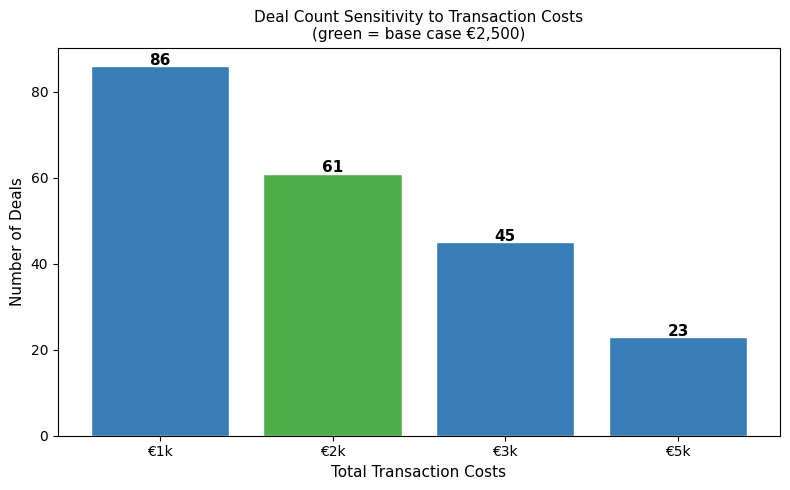

In [11]:
# ── Plot 4: Transaction cost sensitivity ──────────────────────────────────────
cost_scenarios = [1_500, 2_500, 3_500, 5_000]
deal_counts = []
for cost in cost_scenarios:
    nm = df_eng['gross_margin_eur'] - cost
    n = (
        (nm > MIN_NET_MARGIN_EUR) &
        (df_eng['sale_prob_14d'] > MIN_SALE_PROB_14D) &
        (df_eng['price_eur'] > MIN_PRICE_EUR) &
        (df_eng['it_predicted_price'] > df_eng['price_eur']) &
        (df_eng['price_eur'].notna())
    ).sum()
    deal_counts.append(n)
    print(f"Costs €{cost:,}: {n} deals")

fig, ax = plt.subplots(figsize=(8, 5))
bar_colors = ['#4daf4a' if c == TOTAL_TRANSACTION_COST else '#377eb8' for c in cost_scenarios]
bars = ax.bar([f'€{c//1000}k' for c in cost_scenarios], deal_counts, color=bar_colors, edgecolor='white')
for bar, n in zip(bars, deal_counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, str(n),
            ha='center', fontsize=11, fontweight='bold')
ax.set_xlabel('Total Transaction Costs', fontsize=11)
ax.set_ylabel('Number of Deals', fontsize=11)
ax.set_title('Deal Count Sensitivity to Transaction Costs\n(green = base case €2,500)', fontsize=11)
plt.tight_layout()
plt.show()

## 7 — SHAP: Why Does the IT Model Price These Cars High?


Deal #1: Audi Q4 e-tron 50 quattro 82kWh Kamera/ACC/LED/Navi
  DE asking: €25,999  |  DE fair: €25,645  |  IT predicted: €33,850
  Net margin after costs: €5,351


<Figure size 1200x300 with 0 Axes>

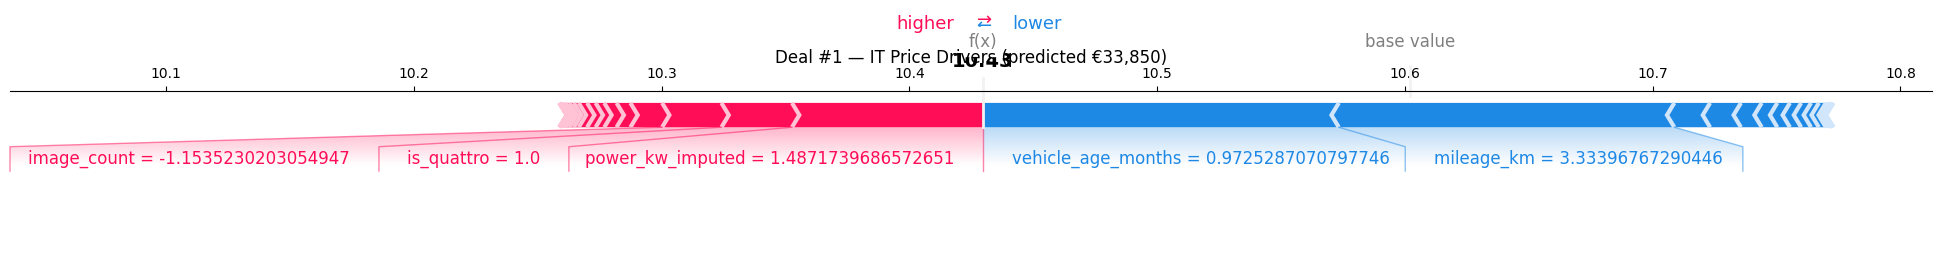


Deal #2: Audi Q4 e-tron 35 *LED *Standheizung *PDC *DAB *Navi
  DE asking: €24,790  |  DE fair: €27,218  |  IT predicted: €32,766
  Net margin after costs: €5,476


<Figure size 1200x300 with 0 Axes>

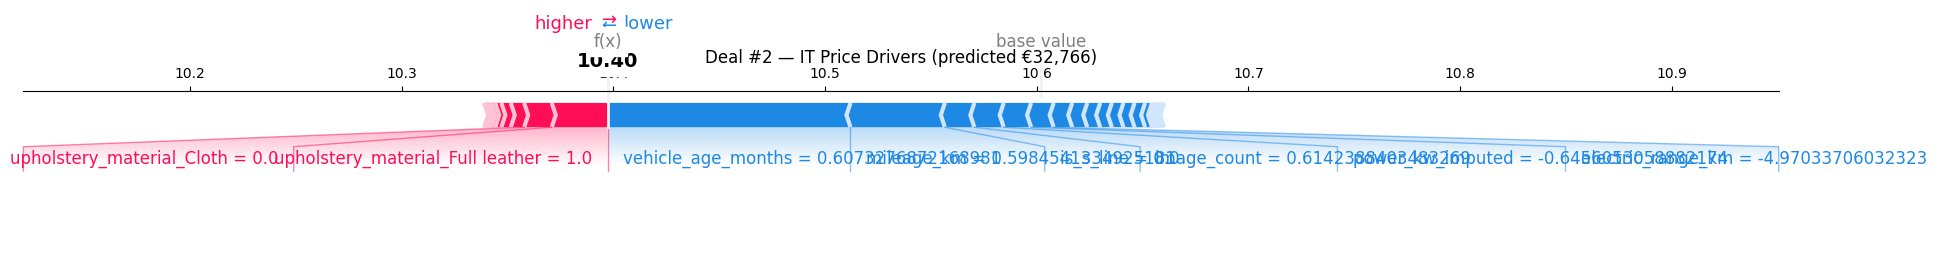


Deal #3: Audi Q4 e-tron SUV (mit Eroberung BEV) SITZHG,NAVI
  DE asking: €37,990  |  DE fair: €39,012  |  IT predicted: €46,241
  Net margin after costs: €5,751


<Figure size 1200x300 with 0 Axes>

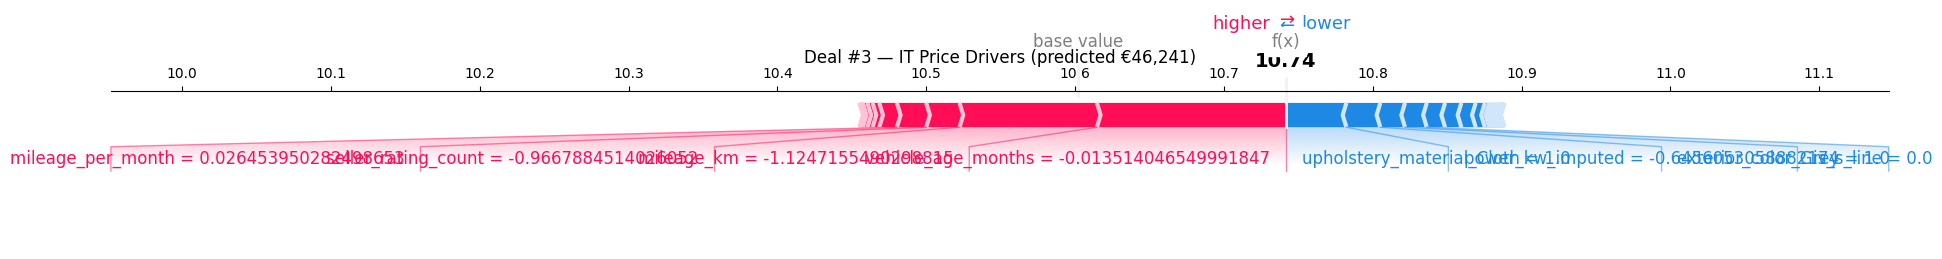


Deal #4: Audi Q4 e-tron Q4 SUV (mit Eroberung BEV) SITZHG,NAVI
  DE asking: €37,990  |  DE fair: €39,012  |  IT predicted: €46,241
  Net margin after costs: €5,751


<Figure size 1200x300 with 0 Axes>

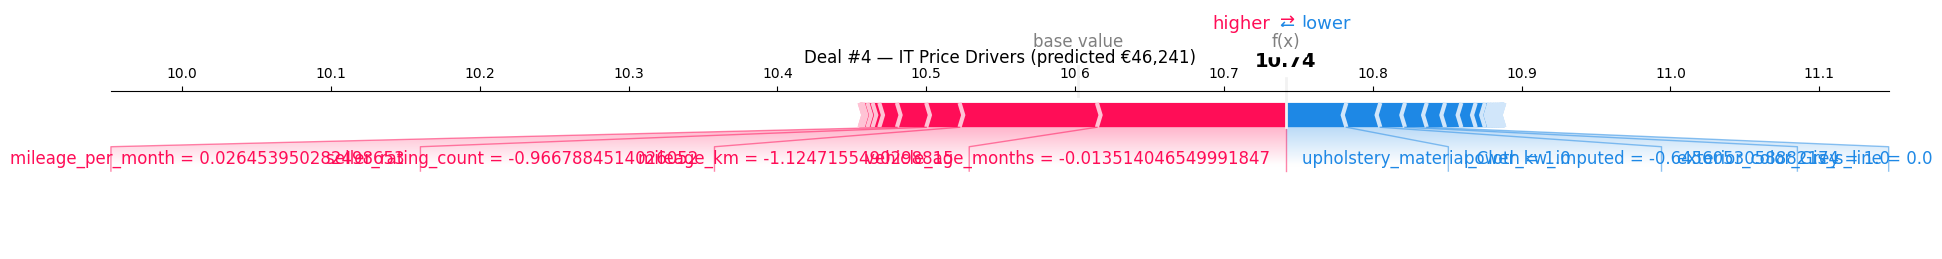


Deal #5: Audi Q4 e-tron Q4 SUV e-tron
  DE asking: €36,490  |  DE fair: €37,687  |  IT predicted: €47,101
  Net margin after costs: €8,111


<Figure size 1200x300 with 0 Axes>

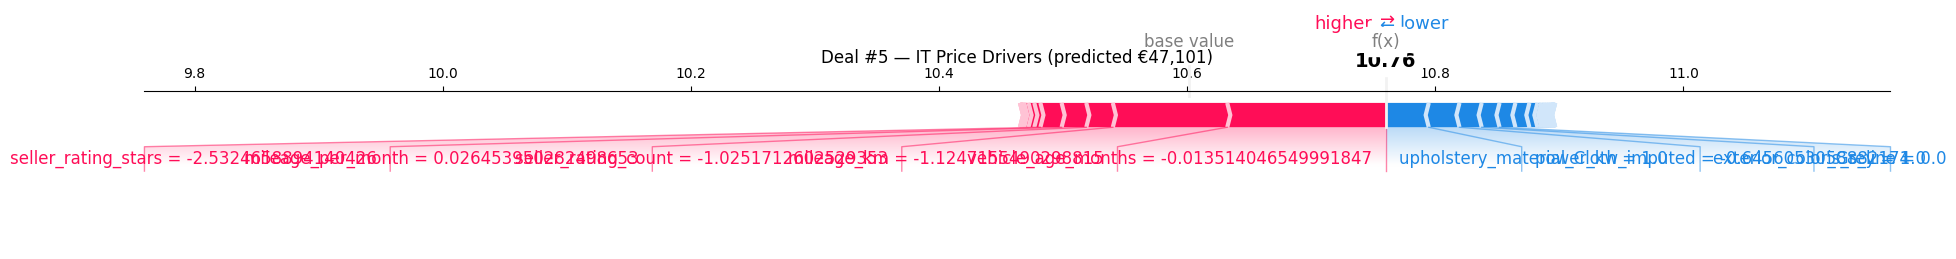

In [12]:
if len(deals) >= 1:
    d_num = df_eng[
        (df_eng['net_margin_eur'] > MIN_NET_MARGIN_EUR) &
        (df_eng['sale_prob_14d']  > MIN_SALE_PROB_14D) &
        (df_eng['price_eur']      > MIN_PRICE_EUR) &
        (df_eng['it_predicted_price'] > df_eng['price_eur']) &
        (df_eng['price_eur'].notna())
    ].sort_values('arbitrage_score', ascending=False).head(5).reset_index(drop=True)

    IT_FEAT_COLS = it_price_meta['feature_cols']

    X_top5 = prepare_for_model(d_num, IT_FEAT_COLS, it_price_meta)

    preprocessor_it = it_price_model.named_steps['pre']
    model_it        = it_price_model.named_steps['model']
    X_top5_tr       = preprocessor_it.transform(X_top5)

    try:
        if it_price_meta.get('best_model_name') == 'XGBoost':
            explainer_it = shap.TreeExplainer(model_it,
                                              feature_perturbation='tree_path_dependent')
        else:
            explainer_it = shap.TreeExplainer(model_it)
        shap_vals    = explainer_it.shap_values(X_top5_tr)
        expected_val = explainer_it.expected_value
        if isinstance(expected_val, np.ndarray):
            expected_val = float(expected_val[0])

        # Feature names for IT model
        num_names  = it_price_meta['numeric_features']
        ord_names  = it_price_meta['categorical_ordinal']
        ohe_names  = list(preprocessor_it.named_transformers_['cat_ohe']
                          .named_steps['enc']
                          .get_feature_names_out(it_price_meta['categorical_nominal']))
        bin_names  = it_price_meta['binary_features']
        feat_names = num_names + ord_names + ohe_names + bin_names

        for i, row in d_num.iterrows():
            pred_it = row['it_predicted_price']
            pred_de = row['de_fair_price']
            ask     = row['price_eur']
            margin  = row['net_margin_eur']
            title   = str(row.get('title', 'Unknown'))[:60]

            print(f"\n{'='*70}")
            print(f"Deal #{i+1}: {title}")
            print(f"  DE asking: €{ask:,.0f}  |  DE fair: €{pred_de:,.0f}  |  IT predicted: €{pred_it:,.0f}")
            print(f"  Net margin after costs: €{margin:,.0f}")

            plt.figure(figsize=(12, 3))
            shap.force_plot(
                expected_val,
                shap_vals[i],
                X_top5_tr[i],
                feature_names=feat_names,
                matplotlib=True,
                show=False,
            )
            plt.title(f"Deal #{i+1} — IT Price Drivers (predicted €{pred_it:,.0f})", pad=20)
            plt.tight_layout()
            plt.show()

    except Exception as e:
        print(f"SHAP force plot unavailable: {e}")
        print("Showing mean feature importances for IT model instead.")
        if hasattr(model_it, 'feature_importances_'):
            num_n  = it_price_meta['numeric_features']
            ord_n  = it_price_meta['categorical_ordinal']
            ohe_n  = list(preprocessor_it.named_transformers_['cat_ohe']
                          .named_steps['enc']
                          .get_feature_names_out(it_price_meta['categorical_nominal']))
            bin_n  = it_price_meta['binary_features']
            feat_n = num_n + ord_n + ohe_n + bin_n
            imp    = model_it.feature_importances_
            top_i  = np.argsort(imp)[-15:]
            plt.figure(figsize=(9, 6))
            plt.barh([feat_n[i] for i in top_i], imp[top_i], color='steelblue')
            plt.xlabel('Feature Importance')
            plt.title('IT Model — Top 15 Features')
            plt.tight_layout()
            plt.show()
else:
    print("Not enough deals for SHAP analysis.")

## 8 — Export Arbitrage Report

In [13]:
OUTPUT_COLS = [
    'title', 'price_eur', 'de_fair_price', 'de_discount_eur',
    'it_predicted_price', 'gross_margin_eur', 'net_margin_eur',
    'it_premium_pct', 'sale_prob_14d', 'arbitrage_score',
    'model_number_v2', 'variant', 'mileage_km', 'vehicle_age_months',
    'city', 'seller_name', 'listing_url',
]

# Use the numeric (pre-formatting) deals dataframe
d_export = df_eng[
    (df_eng['net_margin_eur'] > MIN_NET_MARGIN_EUR) &
    (df_eng['sale_prob_14d']  > MIN_SALE_PROB_14D) &
    (df_eng['price_eur']      > MIN_PRICE_EUR) &
    (df_eng['it_predicted_price'] > df_eng['price_eur']) &
    (df_eng['price_eur'].notna())
].sort_values('arbitrage_score', ascending=False).reset_index(drop=True)
d_export.index += 1
d_export.index.name = 'rank'

report_path = f"arbitrage_report_{datetime.today():%Y%m%d}.csv"
d_export[OUTPUT_COLS].to_csv(report_path, index=True, encoding='utf-8')

print(f"{'='*55}")
print(f"CROSS-MARKET ARBITRAGE REPORT")
print(f"{'='*55}")
print(f"Scrape date:               {latest_csv.stem.split('_')[3] if len(latest_csv.stem.split('_')) > 3 else 'unknown'}")
print(f"Total DE listings scored:  {len(df_eng)}")
print(f"Opportunities found:       {len(d_export)}")
print(f"Transaction cost assumed:  €{TOTAL_TRANSACTION_COST:,}")
if len(d_export) > 0:
    print(f"Total gross margin pool:   €{d_export['gross_margin_eur'].sum():,.0f}")
    print(f"Total net margin pool:     €{d_export['net_margin_eur'].sum():,.0f}")
    print(f"Best deal net margin:      €{d_export['net_margin_eur'].max():,.0f}")
    print(f"Best deal arbitrage score: {d_export['arbitrage_score'].max():,.0f}")
    print(f"Avg sale probability:      {d_export['sale_prob_14d'].mean():.1%}")
print(f"\nReport saved: {report_path}")

CROSS-MARKET ARBITRAGE REPORT
Scrape date:               20260514
Total DE listings scored:  1365
Opportunities found:       61
Transaction cost assumed:  €2,500
Total gross margin pool:   €375,943
Total net margin pool:     €223,443
Best deal net margin:      €8,111
Best deal arbitrage score: 4,412
Avg sale probability:      63.9%

Report saved: arbitrage_report_20260522.csv
